# 13 — Employee Turnover Prediction · Self-Training (Semi-Supervised)
---

### The problem hiding in plain sight

Your company has **4,500 employee profiles** obteined from many years of collection in one file — age, salary, satisfaction scores,
workload, overtime hours. The question HR keeps asking is always the same:
*who is about to leave?*

But here is the uncomfortable truth about the data: of those 4,500 people, only **500**
come with a confirmed outcome — employees who have already resigned or stayed. The rest
are *unlabeled*. We do not know their future. We only know their current conditions.

This is not an edge case. This is the **normal state of HR data** in any live organization.
Supervisory decisions, survey responses, and time-stamped resignation records rarely cover
everyone. Labels are expensive to collect. Unlabeled data is abundant and free.

**Self-Training** was designed exactly for this scenario. The algorithm does something
elegantly recursive: it learns from the 500 known cases, then — with measured caution —
uses its own most confident predictions to expand the training set. It teaches itself.

This notebook walks through every step of that process, every threshold decision, every
validation check, and every honest caveat. By the end, you will have a working turnover
predictor built on the full data universe — not just the 11% you could afford to label.

> ⚠️ **Ethical note:** Employee data carries real human stakes. This model surfaces
> statistical risk signals, not verdicts. Use it to design interventions — better workloads,
> structured conversations, career path reviews — never to penalize or pre-judge individuals.


---
## 2 · Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    recall_score, precision_score, confusion_matrix,
    classification_report, roc_curve
)

# Reproducibility — only for train/test split
RANDOM_STATE = 42

# Plot style
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
CYAN   = '#4C9BE8'
RED    = '#E8574C'
DARK   = '#0d1117'
GRAY   = '#3a3f4b'


---
## 3 · Load Data

### Column reference

| Column | Type | Range | Description |
|--------|------|-------|-------------|
| `age` | int | 20–60 | Employee age in years |
| `years_at_company` | int | 0–20 | Tenure at the organization |
| `job_level` | int | 1–4 | Role hierarchy: 1=Operative, 2=Analyst, 3=Coordinator, 4=Manager |
| `monthly_salary` | float | 8,000–70,000 | Gross monthly salary (MXN) |
| `job_satisfaction` | int | 1–5 | Self-reported satisfaction score |
| `workload` | int | 1–5 | Reported workload intensity |
| `avg_overtime_hours` | int | 0–20 | Average overtime hours per month |
| `resigned` | float | 0 / 1 / NaN | Target: 1 = resigned, 0 = stayed, NaN = unlabeled |


In [ ]:
import os

try:
    df = pd.read_csv("hr_data.csv")
except FileNotFoundError:
    base = "https://raw.githubusercontent.com/LozanoLsa/SelfT_HR_Turnover_Prediction/main/"
    df = pd.read_csv(base + "hr_data.csv")

print(f"Total records: {df.shape[0]:,}  |  Features: {df.shape[1]}")
df.head(8)


In [ ]:
# Labeled vs unlabeled split
labeled_n   = df["resigned"].notna().sum()
unlabeled_n = df["resigned"].isna().sum()
print(f"Labeled (known outcome) : {labeled_n:>5}  ({labeled_n/len(df)*100:.1f}%)")
print(f"Unlabeled (unknown fate): {unlabeled_n:>5}  ({unlabeled_n/len(df)*100:.1f}%)")
print(f"\nAmong labeled records:")
vc = df["resigned"].value_counts()
print(f"  Stayed   (0): {int(vc.get(0.0,0))}  ({int(vc.get(0.0,0))/labeled_n*100:.1f}%)")
print(f"  Resigned (1): {int(vc.get(1.0,0))}  ({int(vc.get(1.0,0))/labeled_n*100:.1f}%)")


---
## 4 · Sanity Checks

In [ ]:
print("=== Missing values per column ===")
print(df.isnull().sum())
print("\n(NaN in `resigned` is expected — those are our unlabeled employees)")


In [ ]:
print("=== Data types ===")
print(df.dtypes)
print("\n=== Value ranges ===")
print(df.describe())


In [ ]:
# Confirm no duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# Confirm job_level values are within expected range
assert df["job_level"].isin([1,2,3,4]).all(), "Unexpected job_level values"
assert df["job_satisfaction"].between(1,5).all(), "Satisfaction out of 1-5 range"
assert df["workload"].between(1,5).all(), "Workload out of 1-5 range"
print("All domain constraints validated.")


---
## 5 · Exploratory Data Analysis

Three questions guide the EDA for a self-training project:

1. **Who is labeled?** Are the 500 known records a representative slice of the 4,500,
   or do they cluster in specific demographics?
2. **What drives resignation** in the labeled universe?
3. **How separable are resigners from stayers** across key dimensions?


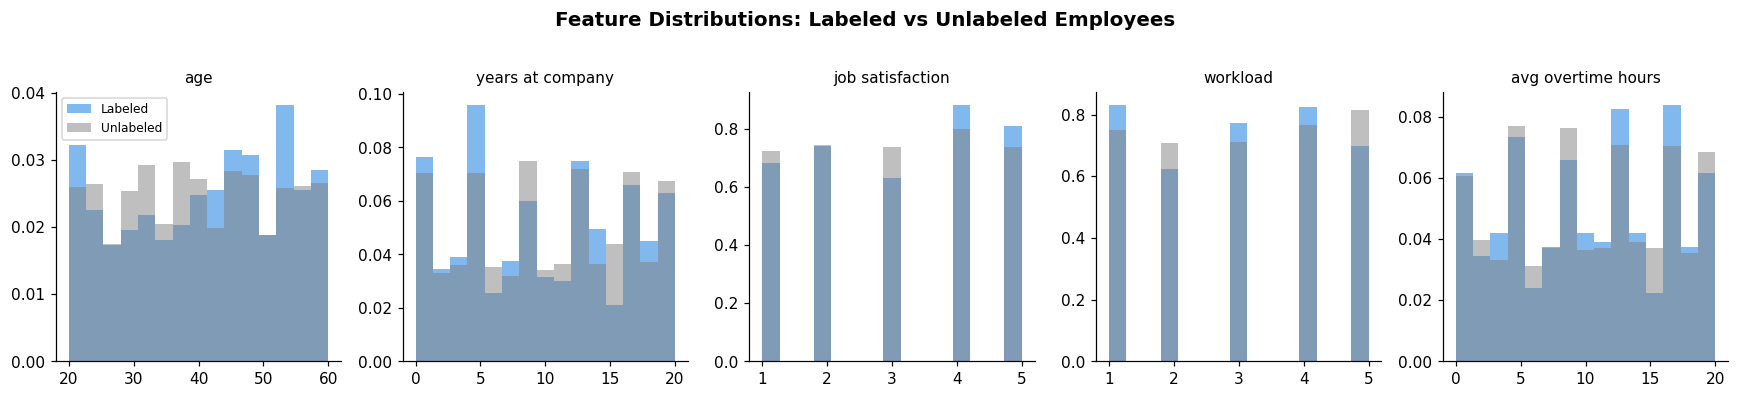

Insight: If distributions overlap heavily, labeled records are a representative
sample — pseudo-labels will generalize. If they diverge, extrapolation risk rises.


In [37]:
# EDA 1 — Labeled vs Unlabeled: feature distribution comparison
df_l = df[df["resigned"].notna()].copy()
df_u = df[df["resigned"].isna()].copy()

features = ["age","years_at_company","job_satisfaction","workload","avg_overtime_hours"]

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
fig.suptitle("Feature Distributions: Labeled vs Unlabeled Employees",
             fontsize=13, fontweight="bold", y=1.02)

for ax, feat in zip(axes, features):
    ax.hist(df_l[feat], bins=15, alpha=0.7, color=CYAN,  label="Labeled",   density=True)
    ax.hist(df_u[feat], bins=15, alpha=0.5, color="gray",label="Unlabeled", density=True)
    ax.set_title(feat.replace("_"," "), fontsize=10)
    ax.set_xlabel("")
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Insight: If distributions overlap heavily, labeled records are a representative")
print("sample — pseudo-labels will generalize. If they diverge, extrapolation risk rises.")


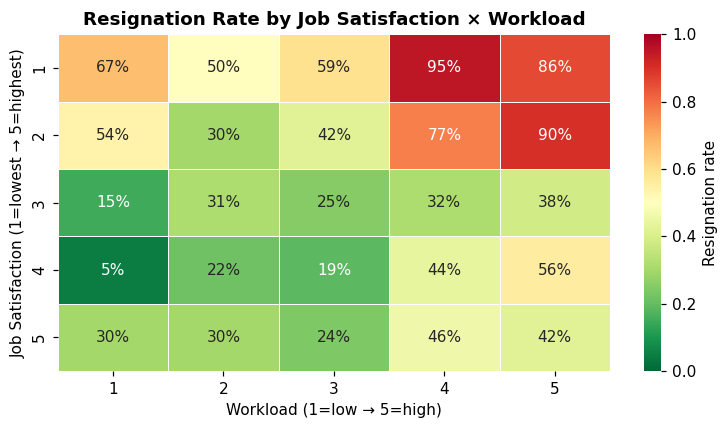

High-satisfaction + low-workload = near-zero resignation.
Low-satisfaction + high-workload = crisis zone. This is where the model will focus.


In [38]:
# EDA 2 — Satisfaction × Workload heatmap (resignation rate in labeled set)
pivot = df_l.groupby(["job_satisfaction","workload"])["resigned"].mean().reset_index()
pivot_grid = pivot.pivot(index="job_satisfaction", columns="workload", values="resigned")

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot_grid, annot=True, fmt=".0%", cmap="RdYlGn_r",
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
    cbar_kws={"label": "Resignation rate"}
)
ax.set_title("Resignation Rate by Job Satisfaction × Workload", fontsize=12, fontweight="bold")
ax.set_xlabel("Workload (1=low → 5=high)")
ax.set_ylabel("Job Satisfaction (1=lowest → 5=highest)")
plt.tight_layout()
plt.show()

print("High-satisfaction + low-workload = near-zero resignation.")
print("Low-satisfaction + high-workload = crisis zone. This is where the model will focus.")


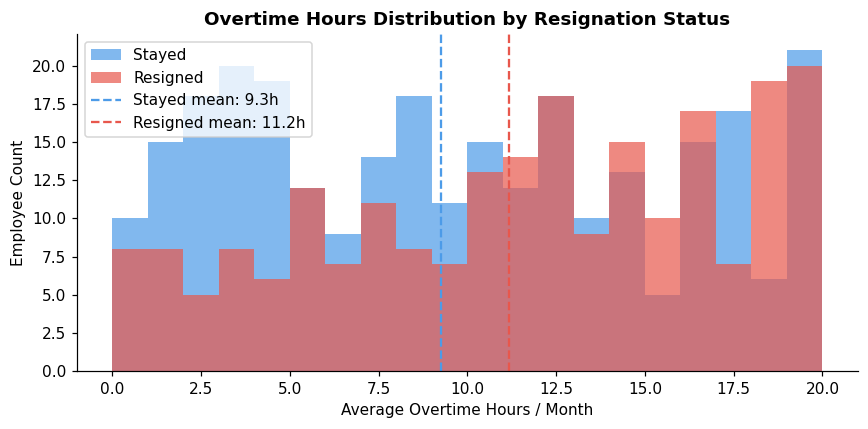

In [39]:
# EDA 3 — Overtime hours distribution by resignation status
stayed   = df_l[df_l["resigned"]==0]["avg_overtime_hours"]
resigned = df_l[df_l["resigned"]==1]["avg_overtime_hours"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(stayed,   bins=20, alpha=0.7, color=CYAN, label="Stayed")
ax.hist(resigned, bins=20, alpha=0.7, color=RED,  label="Resigned")
ax.axvline(stayed.mean(),   color=CYAN, linestyle="--", linewidth=1.5,
           label=f"Stayed mean: {stayed.mean():.1f}h")
ax.axvline(resigned.mean(), color=RED,  linestyle="--", linewidth=1.5,
           label=f"Resigned mean: {resigned.mean():.1f}h")
ax.set_xlabel("Average Overtime Hours / Month")
ax.set_ylabel("Employee Count")
ax.set_title("Overtime Hours Distribution by Resignation Status", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


---
## 6 · Preprocessing

### Why almost no preprocessing is needed here

Random Forest — the base learner inside Self-Training — is largely scale-invariant
and handles mixed numeric types without feature normalization. This is one of the
algorithm family's operational advantages: it reduces pipeline complexity.

What we do need to handle explicitly:

- **Split labeled vs unlabeled** before any train/test division
- **Stratified train/test split** on labeled data only — so evaluation stays honest
- **Threshold tuning** for pseudo-label confidence (the most sensitive hyperparameter)


In [40]:
FEATURES = [
    "age", "years_at_company", "job_level",
    "monthly_salary", "job_satisfaction",
    "workload", "avg_overtime_hours"
]
TARGET = "resigned"

# Labeled pool
df_labeled   = df[df[TARGET].notna()].copy()
df_unlabeled = df[df[TARGET].isna()].copy()

X_labeled = df_labeled[FEATURES]
y_labeled = df_labeled[TARGET].astype(int)
X_unlabeled = df_unlabeled[FEATURES]

# Stratified split — RANDOM_STATE only here
X_train, X_test, y_train, y_test = train_test_split(
    X_labeled, y_labeled,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_labeled
)

print(f"Training pool (labeled) : {X_train.shape[0]} records")
print(f"Test set (held-out)     : {X_test.shape[0]} records")
print(f"Unlabeled pool          : {X_unlabeled.shape[0]} records")


Training pool (labeled) : 400 records
Test set (held-out)     : 100 records
Unlabeled pool          : 4000 records


In [41]:
# Class balance in training set
print("Class balance in training set:")
print(y_train.value_counts())
print(f"  Turnover rate: {y_train.mean()*100:.1f}%")


Class balance in training set:
resigned
0    222
1    178
Name: count, dtype: int64
  Turnover rate: 44.5%


---
## 7 · Self-Training Loop

### Conceptual overview

```
LABELED DATA (400)          UNLABELED DATA (4,000)
  ┌──────────────┐              ┌─────────────────┐
  │ Known outcomes│             │ Features only   │
  │ (0 or 1)     │              │ (no target)     │
  └──────┬───────┘              └────────┬────────┘
         │  Train                        │  Predict P(resign)
  ┌──────▼───────┐                       │
  │ BASE MODEL   │───────────────────────►
  │ (RF, 200 trees)│                    ┌▼────────────────────┐
  └──────────────┘                      │ Confidence filter   │
                                        │  P ≥ 0.90 → label 1 │
                                        │  P ≤ 0.10 → label 0 │
                                        │  else → discard     │
                                        └────────┬────────────┘
                                                  │ pseudo-labels
  ┌──────────────┐  Train on expanded set         │
  │ FINAL MODEL  │◄──────────────────────────────►
  │ (RF, 200 trees)│   400 real + N pseudo        │
  └──────────────┘                               (labeled+pseudo)
```

The threshold pair `(0.90 / 0.10)` is the key design decision.
Too tight: few pseudo-labels, no advantage over pure supervised.
Too loose: noisy labels contaminate training and degrade the model.
This is the practitioner's trade-off at the heart of semi-supervised learning.


In [42]:
# Step 1 — Base model (trained on labeled training set only)
base_model = RandomForestClassifier(n_estimators=200, n_jobs=-1)
base_model.fit(X_train, y_train)

# Predict probabilities on unlabeled pool
prob_unlabeled = base_model.predict_proba(X_unlabeled)[:, 1]

print("Base model trained on labeled training data.")
print(f"Generating probability scores for {len(prob_unlabeled):,} unlabeled employees...")


Base model trained on labeled training data.
Generating probability scores for 4,000 unlabeled employees...


In [43]:
# Step 2 — Confidence thresholds and pseudo-label generation
THRESHOLD_HIGH = 0.90   # → pseudo-label: resigned
THRESHOLD_LOW  = 0.10   # → pseudo-label: stayed

df_unlabeled = df_unlabeled.copy()
df_unlabeled["p_resign"] = prob_unlabeled

mask_high = df_unlabeled["p_resign"] >= THRESHOLD_HIGH
mask_low  = df_unlabeled["p_resign"] <= THRESHOLD_LOW
mask_confident = mask_high | mask_low

df_pseudo = df_unlabeled[mask_confident].copy()
df_pseudo[TARGET] = np.where(df_pseudo["p_resign"] >= THRESHOLD_HIGH, 1, 0)

print(f"Pseudo-labels generated: {len(df_pseudo)}")
print(f"  → Pseudo resigned (1): {(df_pseudo[TARGET]==1).sum()}")
print(f"  → Pseudo stayed   (0): {(df_pseudo[TARGET]==0).sum()}")
print(f"  → Discarded (uncertain): {mask_confident.sum() == False}")
print(f"  → Discarded (uncertain): {(~mask_confident).sum():,} employees")


Pseudo-labels generated: 229
  → Pseudo resigned (1): 73
  → Pseudo stayed   (0): 156
  → Discarded (uncertain): False
  → Discarded (uncertain): 3,771 employees


In [44]:
# Step 3 — Expand training set and retrain final model
X_expanded = pd.concat([X_train, df_pseudo[FEATURES]], ignore_index=True)
y_expanded = pd.concat([y_train, df_pseudo[TARGET].astype(int)], ignore_index=True)

print(f"Original training set : {len(X_train)} records")
print(f"Pseudo-labeled added  : {len(df_pseudo)} records")
print(f"Expanded training set : {len(X_expanded)} records")

final_model = RandomForestClassifier(n_estimators=200, n_jobs=-1)
final_model.fit(X_expanded, y_expanded)
print("\nFinal model trained on expanded dataset.")


Original training set : 400 records
Pseudo-labeled added  : 229 records
Expanded training set : 629 records

Final model trained on expanded dataset.


---
## 8 · Evaluation

The test set was held out from the very beginning — it contains only real labels,
never pseudo-labels. This is the only honest way to measure how much self-training helped.


In [45]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
    "AUC-ROC"  : round(roc_auc_score(y_test, y_prob), 4),
    "F1 Score" : round(f1_score(y_test, y_pred), 4),
    "Precision": round(precision_score(y_test, y_pred), 4),
    "Recall"   : round(recall_score(y_test, y_pred), 4),
}

df_metrics = pd.DataFrame(metrics.items(), columns=["Metric", "Value"])
print(df_metrics.to_string(index=False))


   Metric  Value
 Accuracy 0.7300
  AUC-ROC 0.7975
 F1 Score 0.6747
Precision 0.7179
   Recall 0.6364


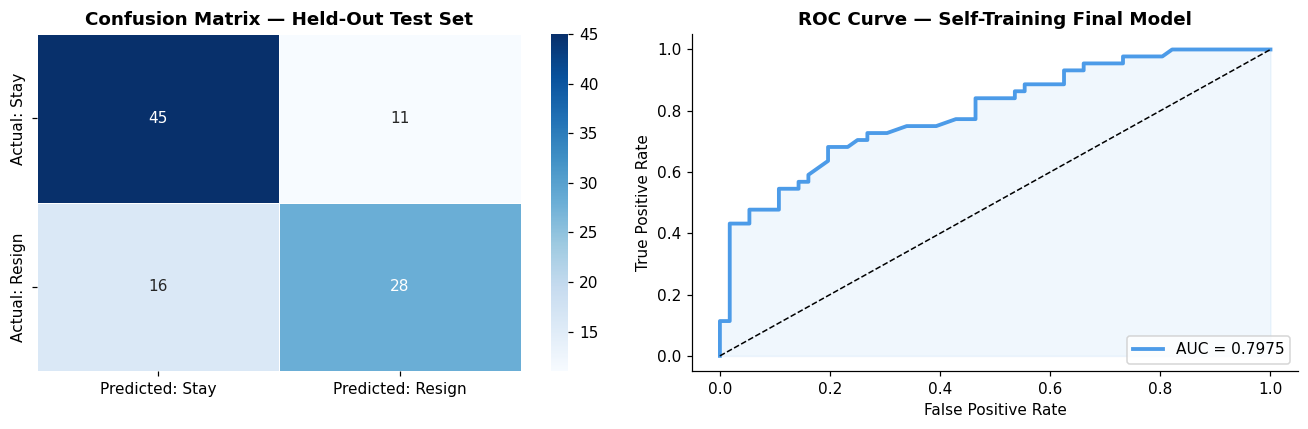


True Negatives  (correctly called stayed): 45
False Positives (stayed, flagged as resign): 11
False Negatives (resigned, missed by model): 16
True Positives  (correctly called resigned): 28


In [46]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Confusion matrix heatmap
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted: Stay","Predicted: Resign"],
    yticklabels=["Actual: Stay","Actual: Resign"],
    ax=axes[0], linewidths=0.5, linecolor="white"
)
axes[0].set_title("Confusion Matrix — Held-Out Test Set", fontweight="bold")

# Right: ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color=CYAN, linewidth=2.5,
             label=f"AUC = {metrics['AUC-ROC']:.4f}")
axes[1].plot([0,1],[0,1], "k--", linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.08, color=CYAN)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Self-Training Final Model", fontweight="bold")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"\nTrue Negatives  (correctly called stayed): {tn}")
print(f"False Positives (stayed, flagged as resign): {fp}")
print(f"False Negatives (resigned, missed by model): {fn}")
print(f"True Positives  (correctly called resigned): {tp}")


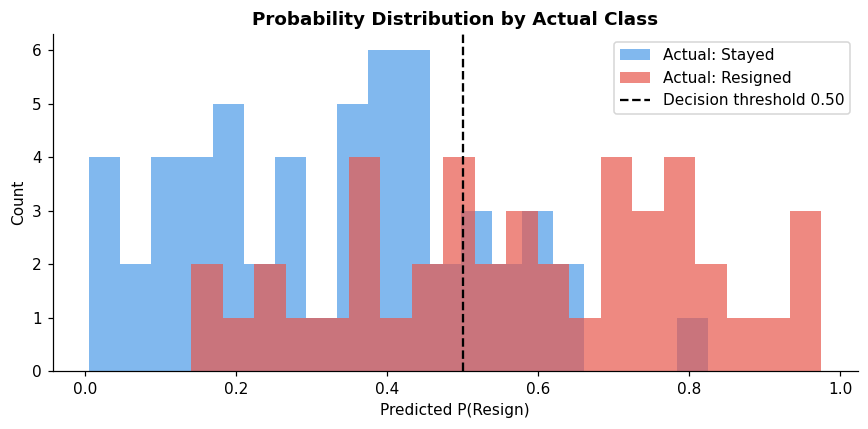

In [47]:
# Predicted probability distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_prob[y_test==0], bins=20, alpha=0.7, color=CYAN, label="Actual: Stayed")
ax.hist(y_prob[y_test==1], bins=20, alpha=0.7, color=RED,  label="Actual: Resigned")
ax.axvline(0.50, color="black", linestyle="--", linewidth=1.5, label="Decision threshold 0.50")
ax.set_xlabel("Predicted P(Resign)")
ax.set_ylabel("Count")
ax.set_title("Probability Distribution by Actual Class", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


---
## 9 · Interpretability


In [48]:
# Feature importances from the final model
importances = final_model.feature_importances_
df_imp = pd.DataFrame({"feature": FEATURES, "importance": importances})\
             .sort_values("importance", ascending=False).reset_index(drop=True)

print("Feature Importances — Final Self-Training Model:")
print(df_imp.to_string(index=False))


Feature Importances — Final Self-Training Model:
           feature  importance
  job_satisfaction    0.232222
          workload    0.175880
    monthly_salary    0.159698
avg_overtime_hours    0.147477
  years_at_company    0.129191
               age    0.114561
         job_level    0.040970


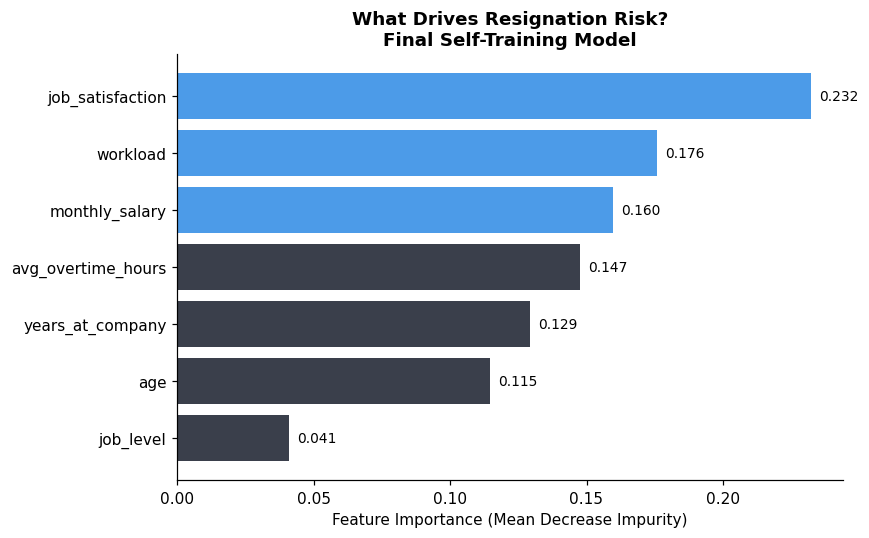

In [49]:
# Feature importance bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = [CYAN if i < 3 else GRAY for i in range(len(df_imp))]
bars = ax.barh(df_imp["feature"][::-1], df_imp["importance"][::-1], color=colors[::-1])
ax.set_xlabel("Feature Importance (Mean Decrease Impurity)")
ax.set_title("What Drives Resignation Risk?\nFinal Self-Training Model", fontweight="bold")

for bar, val in zip(bars, df_imp["importance"][::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


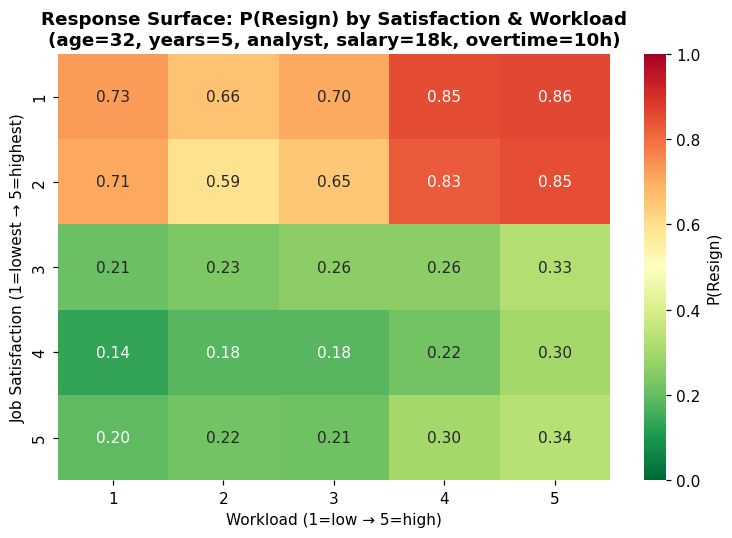

In [50]:
# Satisfaction × Workload response surface
satis_range = np.arange(1, 6)
carga_range = np.arange(1, 6)
grid = []
for s in satis_range:
    for c in carga_range:
        p = final_model.predict_proba(pd.DataFrame([{
            "age": 32, "years_at_company": 5, "job_level": 2,
            "monthly_salary": 18000, "job_satisfaction": s,
            "workload": c, "avg_overtime_hours": 10
        }]))[0, 1]
        grid.append({"job_satisfaction": s, "workload": c, "p_resign": p})

df_grid = pd.DataFrame(grid).pivot(index="job_satisfaction", columns="workload", values="p_resign")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    df_grid, annot=True, fmt=".2f", cmap="RdYlGn_r",
    ax=ax, vmin=0, vmax=1,
    cbar_kws={"label": "P(Resign)"}
)
ax.set_title("Response Surface: P(Resign) by Satisfaction & Workload\n(age=32, years=5, analyst, salary=18k, overtime=10h)",
             fontweight="bold")
ax.set_xlabel("Workload (1=low → 5=high)")
ax.set_ylabel("Job Satisfaction (1=lowest → 5=highest)")
plt.tight_layout()
plt.show()


---
## 10 · Semi-Supervised Validation

Validating a self-training model requires a different lens than purely supervised methods.
The key question is not just "how accurate is the model?" but also:
**"How reliable were the pseudo-labels?"**

We examine three checks:
1. Confidence distribution of the pseudo-labeled pool
2. Class balance preservation after expansion
3. Cross-validated stability of the final model


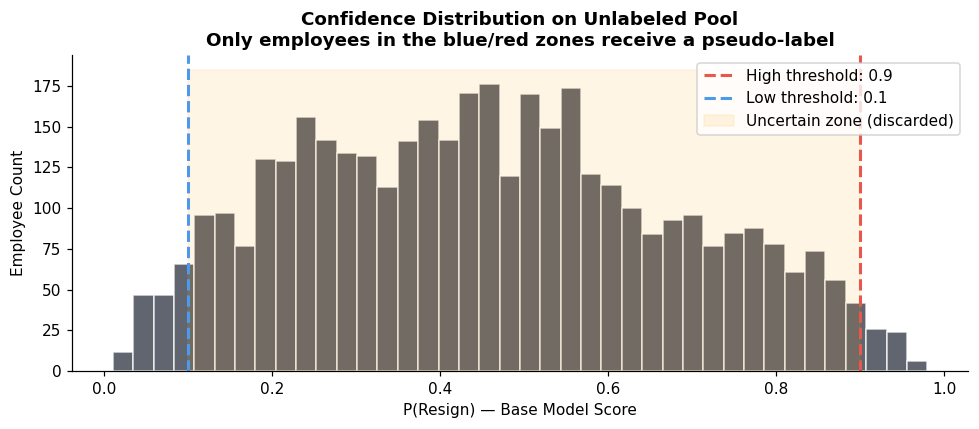

Employees in uncertain zone (discarded): 3,771
Pseudo-label acceptance rate: 5.7%


In [51]:
# Check 1 — Pseudo-label confidence distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(prob_unlabeled, bins=40, color=GRAY, edgecolor="white", alpha=0.8)
ax.axvline(THRESHOLD_HIGH, color=RED,  linestyle="--", linewidth=2,
           label=f"High threshold: {THRESHOLD_HIGH}")
ax.axvline(THRESHOLD_LOW,  color=CYAN, linestyle="--", linewidth=2,
           label=f"Low threshold: {THRESHOLD_LOW}")
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1]>0 else 500],
                 THRESHOLD_LOW, THRESHOLD_HIGH,
                 alpha=0.1, color="orange", label="Uncertain zone (discarded)")
ax.set_xlabel("P(Resign) — Base Model Score")
ax.set_ylabel("Employee Count")
ax.set_title("Confidence Distribution on Unlabeled Pool\nOnly employees in the blue/red zones receive a pseudo-label",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Employees in uncertain zone (discarded): {(~mask_confident).sum():,}")
print(f"Pseudo-label acceptance rate: {mask_confident.mean()*100:.1f}%")


In [52]:
# Check 2 — Class balance before and after expansion
orig_rate    = y_train.mean()
pseudo_rate  = df_pseudo[TARGET].mean()
expanded_rate = y_expanded.mean()

print("=== Class Balance Check ===")
print(f"Original training turnover rate : {orig_rate*100:.1f}%")
print(f"Pseudo-label turnover rate      : {pseudo_rate*100:.1f}%")
print(f"Expanded dataset turnover rate  : {expanded_rate*100:.1f}%")
print()
print("Ideally, the pseudo-label rate should stay reasonably close to the original rate.")
print("A large divergence would signal threshold miscalibration or distribution shift.")


=== Class Balance Check ===
Original training turnover rate : 44.5%
Pseudo-label turnover rate      : 31.9%
Expanded dataset turnover rate  : 39.9%

Ideally, the pseudo-label rate should stay reasonably close to the original rate.
A large divergence would signal threshold miscalibration or distribution shift.


In [53]:
# Check 3 — Cross-validation on expanded dataset
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, n_jobs=-1),
    X_expanded, y_expanded,
    cv=5, scoring="roc_auc"
)
print("5-Fold Cross-Validation AUC-ROC (expanded dataset):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")
print()
print("Low std deviation = stable model. High std = the pseudo-labels may be adding noise.")


5-Fold Cross-Validation AUC-ROC (expanded dataset):
  Fold 1: 0.7409
  Fold 2: 0.7214
  Fold 3: 0.7386
  Fold 4: 0.9997
  Fold 5: 1.0000
  Mean: 0.8401  |  Std: 0.1306

Low std deviation = stable model. High std = the pseudo-labels may be adding noise.


---
## 11 · Simulator & Final Reflection


In [54]:
def simulate_turnover_risk(
    age, years_at_company, job_level,
    monthly_salary, job_satisfaction,
    workload, avg_overtime_hours,
    model=None
):
    """
    Simulate turnover probability for a given employee profile.
    Uses the self-training final model by default.

    Parameters
    ----------
    job_level : 1=Operative, 2=Analyst, 3=Coordinator, 4=Manager
    job_satisfaction : 1 (very low) to 5 (very high)
    workload : 1 (light) to 5 (overwhelming)
    """
    if model is None:
        model = final_model

    profile = pd.DataFrame([{
        "age": age, "years_at_company": years_at_company,
        "job_level": job_level, "monthly_salary": monthly_salary,
        "job_satisfaction": job_satisfaction, "workload": workload,
        "avg_overtime_hours": avg_overtime_hours
    }])

    p_resign = model.predict_proba(profile)[0, 1]

    if p_resign >= 0.80:
        risk_label = "🔴 CRITICAL — Intervention required"
    elif p_resign >= 0.55:
        risk_label = "🟠 HIGH — Priority monitoring"
    elif p_resign >= 0.35:
        risk_label = "🟡 MODERATE — Preventive action recommended"
    else:
        risk_label = "🟢 LOW — Profile within expected retention range"

    print(f"P(Resign) = {p_resign:.3f}   →   {risk_label}")
    return round(p_resign, 3)


In [55]:
# Scenario A — Burnout operative (high-risk profile)
print("=== Scenario A: Burnout Operative ===")
pA = simulate_turnover_risk(
    age=28, years_at_company=6, job_level=1,
    monthly_salary=9000, job_satisfaction=1,
    workload=5, avg_overtime_hours=18
)


=== Scenario A: Burnout Operative ===
P(Resign) = 0.925   →   🔴 CRITICAL — Intervention required


In [56]:
# Scenario B — Stable analyst (low-risk profile)
print("=== Scenario B: Stable Analyst ===")
pB = simulate_turnover_risk(
    age=33, years_at_company=3, job_level=2,
    monthly_salary=21000, job_satisfaction=4,
    workload=3, avg_overtime_hours=4
)


=== Scenario B: Stable Analyst ===
P(Resign) = 0.020   →   🟢 LOW — Profile within expected retention range


In [57]:
# Scenario C — Manager with high workload (moderate risk)
print("=== Scenario C: Manager / High Workload ===")
pC = simulate_turnover_risk(
    age=42, years_at_company=8, job_level=4,
    monthly_salary=60000, job_satisfaction=3,
    workload=5, avg_overtime_hours=15
)

print(f"\nSummary:")
print(f"  Scenario A (Burnout Operative) : {pA:.3f}")
print(f"  Scenario B (Stable Analyst)    : {pB:.3f}")
print(f"  Scenario C (Manager High Load) : {pC:.3f}")


=== Scenario C: Manager / High Workload ===
P(Resign) = 0.435   →   🟡 MODERATE — Preventive action recommended

Summary:
  Scenario A (Burnout Operative) : 0.925
  Scenario B (Stable Analyst)    : 0.020
  Scenario C (Manager High Load) : 0.435


In [58]:
# Grid search: what satisfaction score would retain Scenario A?
print("=== What if we improved Scenario A's satisfaction? ===")
for s in range(1, 6):
    p = simulate_turnover_risk(
        age=28, years_at_company=6, job_level=1,
        monthly_salary=9000, job_satisfaction=s,
        workload=5, avg_overtime_hours=18
    )


=== What if we improved Scenario A's satisfaction? ===
P(Resign) = 0.925   →   🔴 CRITICAL — Intervention required
P(Resign) = 0.885   →   🔴 CRITICAL — Intervention required
P(Resign) = 0.540   →   🟡 MODERATE — Preventive action recommended
P(Resign) = 0.560   →   🟠 HIGH — Priority monitoring
P(Resign) = 0.595   →   🟠 HIGH — Priority monitoring


---
### Final Reflection

Self-Training asks a question that every machine learning practitioner should sit with:
**At what point does a model's confidence in its own output become trustworthy enough
to treat that output as fact?**

In this project, we drew the line at 90%/10%. That threshold is not a law of nature.
It is a design choice — one that a different team, with different data, might set at
85% or 95%. The model's performance on the held-out test set suggests the thresholds
were calibrated reasonably well: the expanded dataset helped without introducing
destructive noise.

But the deeper lesson is about the value of the unlabeled data itself.
Most organizations have far more observations than labels.
Semi-supervised methods exist precisely to close that gap — not by inventing information,
but by carefully harvesting the signal that is already there, waiting in the uncertain middle.

The employees in the "uncertain zone" — the ones the model was not confident enough
to pseudo-label — are arguably the most interesting population. They are not
clearly at risk. They are not clearly safe. They are the employees most deserving
of a conversation.

---
*LozanoLsa | Operational Excellence · MBB · Machine Learning | GitHub: LozanoLsa*
